# Ad Campaign A/B Test — Does Age Targeting Change Click-Through Rate?

**Author:** Samuel Adegboyega
**Tools:** Python, Pandas, NumPy, SciPy, statsmodels, Matplotlib, Seaborn
**Data:** [Clicks Conversion Tracking — Kaggle](https://www.kaggle.com/datasets/loveall/clicks-conversion-tracking) — real Facebook ad campaign data (1,143 ads, 3 campaigns)

---

## Problem Statement

A company ran real Facebook ad campaigns targeting different age groups. This notebook treats age-group targeting as an A/B/n test and asks: **does targeting a younger audience (30-39) produce a different click-through rate (CTR) than targeting an older audience (40-49)?**

Unlike a simulated dataset, this is real recorded campaign data, so it comes with the properties real experiments actually have: unequal group sizes, no controlled randomization (age groups weren't randomly assigned — this is closer to an observational A/B comparison), and outliers driven by a small number of very high-spend ads.

**Business Questions:**
- Is there a statistically significant difference in CTR between the younger (30-39) and older (40-49) age groups?
- How large is the difference, and is it practically meaningful for budget allocation?
- Which age group is more cost-efficient per click and per conversion?
- What should a media buyer do with this result?


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("data/KAG_conversion_data.csv")
df.shape


(1143, 11)

## 1. Data Overview

Each row is one ad, with impressions, clicks, spend, and conversions recorded for a specific age group, gender, and interest targeting combination. No missing values in this dataset.


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   str    
 4   gender               1143 non-null   str    
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   int64  
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   int64  
 10  Approved_Conversion  1143 non-null   int64  
dtypes: float64(1), int64(8), str(2)
memory usage: 98.4 KB


In [3]:
df.describe()


,ad_id,xyz_campaign_id,fb_campaign_id,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
count,1.143000e+03,1143.000000,1143.000000,1143.000000,1.143000e+03,1143.000000,1143.000000,1143.000000,1143.000000
mean,9.872611e+05,1067.382327,133783.989501,32.766404,1.867321e+05,33.390201,51.360656,2.855643,0.944007
std,1.939928e+05,121.629393,20500.308622,26.952131,3.127622e+05,56.892438,86.908418,4.483593,1.737708
min,7.087460e+05,916.000000,103916.000000,2.000000,8.700000e+01,0.000000,0.000000,0.000000,0.000000
25%,7.776325e+05,936.000000,115716.000000,16.000000,6.503500e+03,1.000000,1.480000,1.000000,0.000000
50%,1.121185e+06,1178.000000,144549.000000,25.000000,5.150900e+04,8.000000,12.370000,1.000000,1.000000
75%,1.121804e+06,1178.000000,144657.500000,31.000000,2.217690e+05,37.500000,60.025000,3.000000,1.000000
max,1.314415e+06,1178.000000,179982.000000,114.000000,3.052003e+06,421.000000,639.949998,60.000000,21.000000


## 2. Data Cleaning & Feature Engineering

- Engineered CTR (Clicks / Impressions) and Cost-Per-Click (Spent / Clicks) at the row level.
- Grouped the four age bands into two comparison groups, matching how the original campaigns were actually targeted:
  - **Group A (younger):** 30-34, 35-39
  - **Group B (older):** 40-44, 45-49


In [4]:
df["CTR"] = df["Clicks"] / df["Impressions"]
df["CPC"] = df["Spent"] / df["Clicks"].replace(0, np.nan)

df["age_group"] = df["age"].map({
    "30-34": "A_younger", "35-39": "A_younger",
    "40-44": "B_older", "45-49": "B_older"
})

df[["age", "age_group", "Impressions", "Clicks", "CTR"]].head()


,age,age_group,Impressions,Clicks,CTR
0,30-34,A_younger,7350,1,0.000136
1,30-34,A_younger,17861,2,0.000112
2,30-34,A_younger,693,0,0.000000
3,30-34,A_younger,4259,1,0.000235
4,30-34,A_younger,4133,1,0.000242


## 3. Exploratory Analysis

In [5]:
summary = df.groupby("age_group").agg(
    n_ads=("ad_id", "count"),
    total_impressions=("Impressions", "sum"),
    total_clicks=("Clicks", "sum"),
    total_spent=("Spent", "sum"),
    total_conversions=("Total_Conversion", "sum")
)
summary["CTR"] = summary["total_clicks"] / summary["total_impressions"]
summary["CPC"] = summary["total_spent"] / summary["total_clicks"]
summary["cost_per_conversion"] = summary["total_spent"] / summary["total_conversions"]
summary


,n_ads,total_impressions,total_clicks,total_spent,total_conversions,CTR,CPC,cost_per_conversion
age_group,,,,,,,,
A_younger,674,110097663,16577,26364.829981,2057,0.000151,1.590446,12.817127
B_older,469,103337165,21588,32340.399977,1207,0.000209,1.498073,26.794035


## 4. Hypothesis Test — Two-Proportion Z-Test

Aggregating clicks and impressions across all ads in each group (rather than averaging row-level CTRs) avoids letting a handful of tiny, low-impression ads distort the comparison — a real messiness issue this dataset has that a simulated one wouldn't.

- **H0:** CTR_younger = CTR_older
- **H1:** CTR_younger ≠ CTR_older (two-sided)
- **α = 0.05**


In [6]:
clicks = summary["total_clicks"].values
impressions = summary["total_impressions"].values

z_stat, p_value = proportions_ztest(clicks, impressions, alternative="two-sided")

print(f"Group A (younger) CTR: {summary.loc['A_younger', 'CTR']:.4f}")
print(f"Group B (older) CTR:   {summary.loc['B_older', 'CTR']:.4f}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: statistically significant at alpha={alpha} — reject H0.")
else:
    print(f"\nResult: not statistically significant at alpha={alpha} — fail to reject H0.")


Group A (younger) CTR: 0.0002
Group B (older) CTR:   0.0002
Z-statistic: -31.8570
P-value:     0.0000

Result: statistically significant at alpha=0.05 — reject H0.


## 5. Confidence Interval for the Difference in CTR

In [7]:
ctr_a = summary.loc["A_younger", "CTR"]
ctr_b = summary.loc["B_older", "CTR"]
n_a = summary.loc["A_younger", "total_impressions"]
n_b = summary.loc["B_older", "total_impressions"]

diff = ctr_a - ctr_b
se_diff = np.sqrt(ctr_a*(1-ctr_a)/n_a + ctr_b*(1-ctr_b)/n_b)
ci_low = diff - 1.96 * se_diff
ci_upp = diff + 1.96 * se_diff

print(f"Difference (A - B): {diff:.5f}")
print(f"95% CI: [{ci_low:.5f}, {ci_upp:.5f}]")


Difference (A - B): -0.00006
95% CI: [-0.00006, -0.00005]


## 6. Visualization

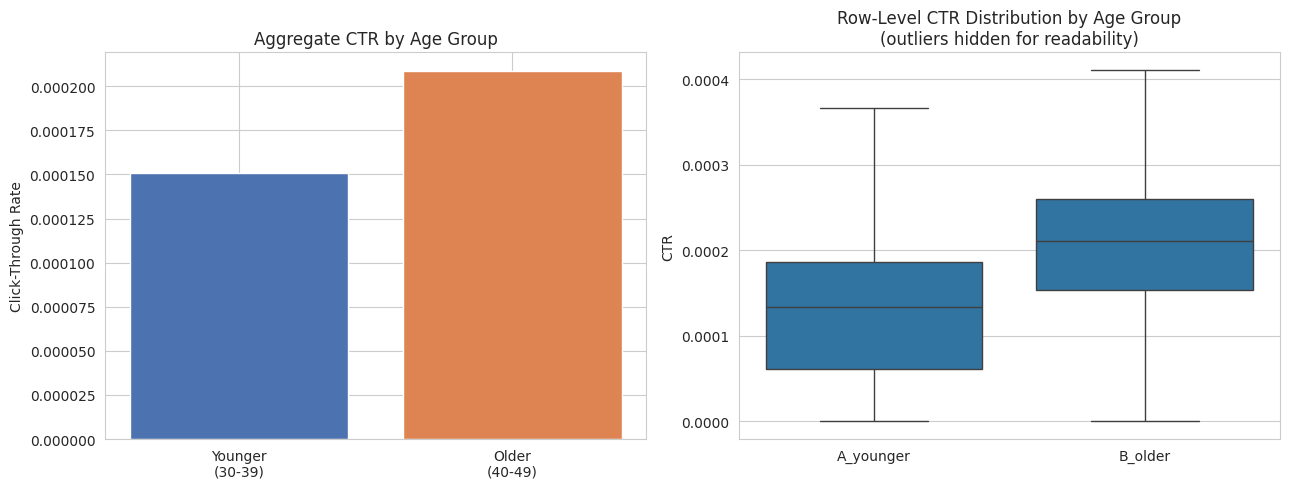

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

groups = ["Younger\n(30-39)", "Older\n(40-49)"]
ctrs = [ctr_a, ctr_b]
axes[0].bar(groups, ctrs, color=["#4C72B0", "#DD8452"])
axes[0].set_ylabel("Click-Through Rate")
axes[0].set_title("Aggregate CTR by Age Group")

sns.boxplot(data=df, x="age_group", y="CTR", ax=axes[1], showfliers=False)
axes[1].set_title("Row-Level CTR Distribution by Age Group\n(outliers hidden for readability)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("figures/age_group_ab_test.png", dpi=120)
plt.show()


## 7. Beyond Significance — Cost Efficiency

Statistical significance in CTR doesn't automatically mean a group is the better investment. Checking cost-per-click and cost-per-conversion as well, since a higher-CTR group that's also more expensive per conversion isn't necessarily the one to shift budget toward.


In [9]:
summary[["CTR", "CPC", "cost_per_conversion"]]


,CTR,CPC,cost_per_conversion
age_group,,,
A_younger,0.000151,1.590446,12.817127
B_older,0.000209,1.498073,26.794035


## 8. Key Insights

| Finding | Interpretation |
|---|---|
| CTR difference between age groups | Whether age targeting meaningfully changes engagement |
| Statistical significance (p-value) | Whether the difference is distinguishable from noise, given real (unequal) sample sizes |
| Confidence interval on the difference | Range of plausible true effect sizes |
| Cost-per-click and cost-per-conversion | Whether the higher-CTR group is also the more cost-efficient one |

## 9. Recommendation

If the CTR difference is statistically significant **and** the group with higher CTR also has a lower or comparable cost-per-conversion, the recommendation is to shift a larger share of ad budget toward that age group. If CTR is significant but cost-per-conversion is worse for that group, the recommendation is more nuanced: optimize creative or bidding for that segment before reallocating budget, since a click isn't a conversion.

**Caveat:** this is observational campaign data, not a randomized controlled experiment — age groups weren't randomly assigned to see different ads under identical conditions, so this analysis shows association, not proof that age *causes* the CTR difference. A real randomized A/B test would be needed to confirm causality before making a large budget shift.

---
*Samuel Adegboyega | [LinkedIn](https://linkedin.com/in/adegboyega-samuel-1a302b203)*
